# Análisis exploratorio de datos - Espectro de respuesta (Ing. Sísmica)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from IPython.display import HTML

In [2]:
df = pd.read_csv(r'C:\Users\elias\OneDrive\Desktop\dataviz_py\eda-jbook\docs\NGACOL.csv')

In [3]:
inputs = df.drop('T_0.01_RotD50', axis=1)
output = df['T_0.01_RotD50']

## Análisis bivariado

### T_0.01_RotD50 vs Rrup_OpenQuake

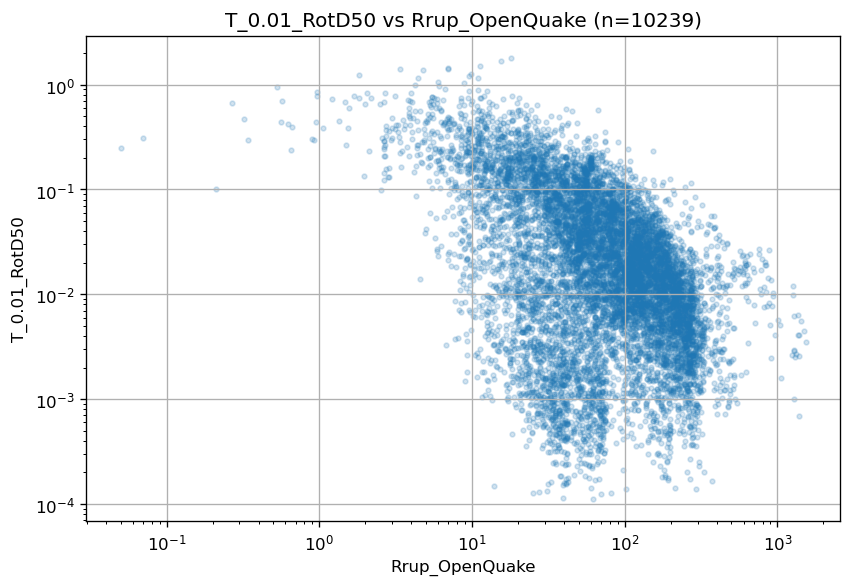

In [4]:
xcol = "Rrup_OpenQuake"
ycol = "T_0.01_RotD50"

d = df[[xcol, ycol]].copy()
d[xcol] = np.exp(pd.to_numeric(d[xcol], errors="coerce"))
d[ycol] = np.exp(pd.to_numeric(d[ycol], errors="coerce"))
d = d.dropna()

if len(d) > 80000:
    d = d.sample(80000, random_state=42)

plt.figure(figsize=(7.2, 5.0), dpi=120)
plt.scatter(d[xcol], d[ycol], s=8, alpha=0.20)
plt.title(f"{ycol} vs {xcol} (n={len(d)})")
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.xscale("log")
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

La famosa curva de atenuación indica que a medida que la distancia de ruptura aumenta, la aceleración disminuirá. Es notoria la manera no lineal en la que disminuye la aceleración frente a la ruptura en la escala log-log

### T_0.01_RotD50 vs Magnitude

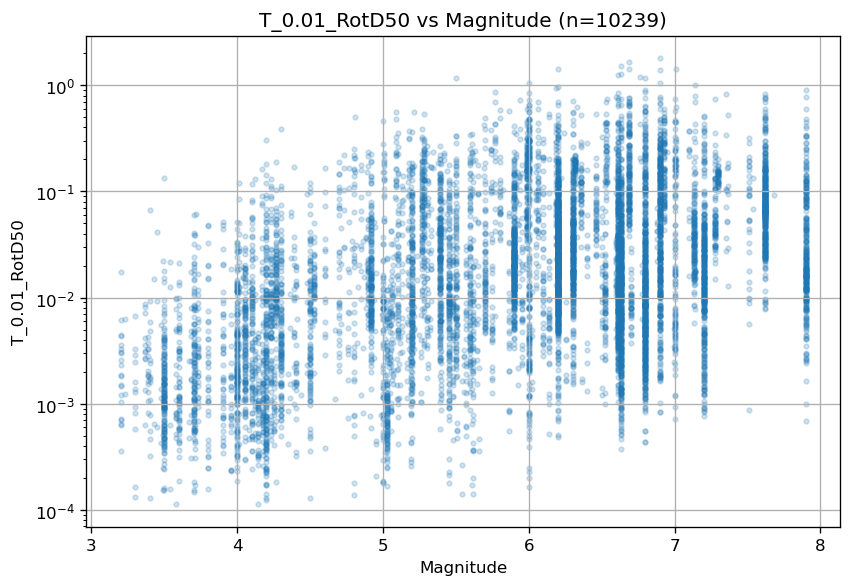

In [5]:

xcol = "Magnitude"
ycol = "T_0.01_RotD50"

d = df[[xcol, ycol]].copy()
d[xcol] = pd.to_numeric(d[xcol], errors="coerce")
d[ycol] = pd.to_numeric(np.exp(d[ycol]), errors="coerce")
d = d.dropna()

if len(d) > 80000:
    d = d.sample(80000, random_state=42)

plt.figure(figsize=(7.2, 5.0), dpi=120)
plt.scatter(d[xcol], d[ycol], s=8, alpha=0.20)
plt.title(f"{ycol} vs {xcol} (n={len(d)})")
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

Se ve una tendencia positiva clara, a mayor magnitud, T_0.01_RotD50 tiende a aumentar .La nube tiene mucha dispersión vertical para una misma magnitud por lo que la Magnitude explica parte importante, pero no basta (distancia, sitio y otros factores están metiendo variabilidad). Las lineas verticales sugieren magnitudes redondeadas

### Hypocenter Depth vs T_0.01_RotD50

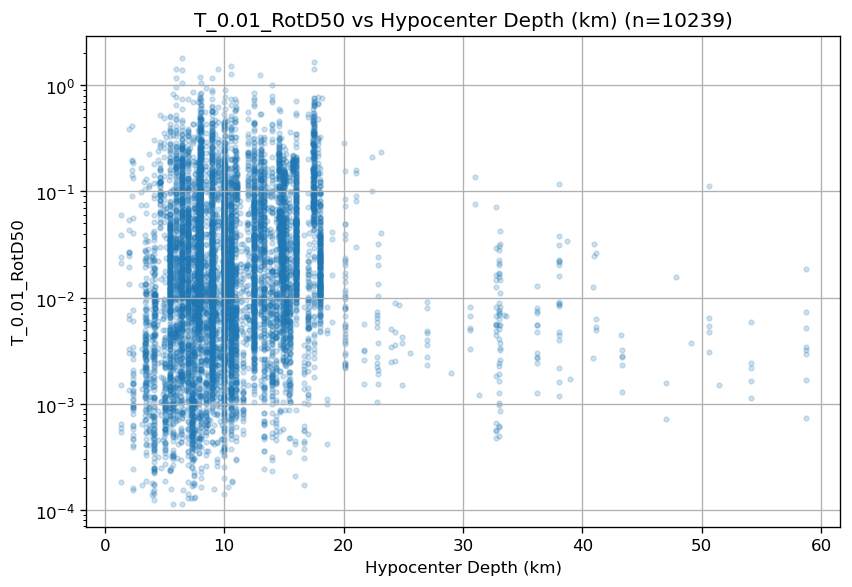

In [6]:
xcol = "Hypocenter Depth (km)"
ycol = "T_0.01_RotD50"

d = df[[xcol, ycol]].copy()
d[xcol] = pd.to_numeric(d[xcol], errors="coerce")
d[ycol] = pd.to_numeric(np.exp(d[ycol]), errors="coerce")
d = d.dropna()

if len(d) > 80000:
    d = d.sample(80000, random_state=42)

plt.figure(figsize=(7.2, 5.0), dpi=120)
plt.scatter(d[xcol], d[ycol], s=8, alpha=0.20)
plt.title(f"{ycol} vs {xcol} (n={len(d)})")
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

La densidad está casi toda entre 0 y 20 km. Para >30 km hay muy pocos puntos. No se aprecia una relación fuerte monotónica con profundidad en el rango dominante (0–20 km).

### Hypocenter Depth vs Rrup_OpenQuake

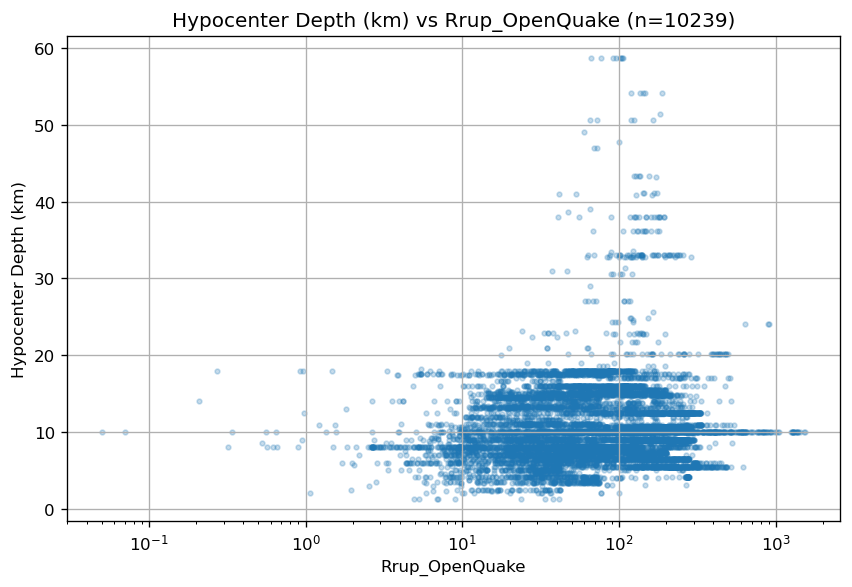

In [7]:
ycol = "Hypocenter Depth (km)"
xcol = "Rrup_OpenQuake"

d = df[[xcol, ycol]].copy()
d[xcol] = np.exp(pd.to_numeric(d[xcol], errors="coerce"))
d[ycol] = pd.to_numeric(d[ycol], errors="coerce")
d = d.dropna()

plt.figure(figsize=(7.2, 5.0), dpi=120)
plt.scatter(d[xcol], d[ycol], s=8, alpha=0.25)
plt.title(f"{ycol} vs {xcol} (n={len(d)})")
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.xscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

La mayoría de registros, Rrup  10–200 km y profundidades  5–15 km.No se ve una relación simple, más bien refleja la composición del dataset. Los eventos más profundos (30–60 km) aparecen, pero son minoría y no dominan ninguna banda clara de distancias

### T_0.01_RotD50 vs Soil_Class

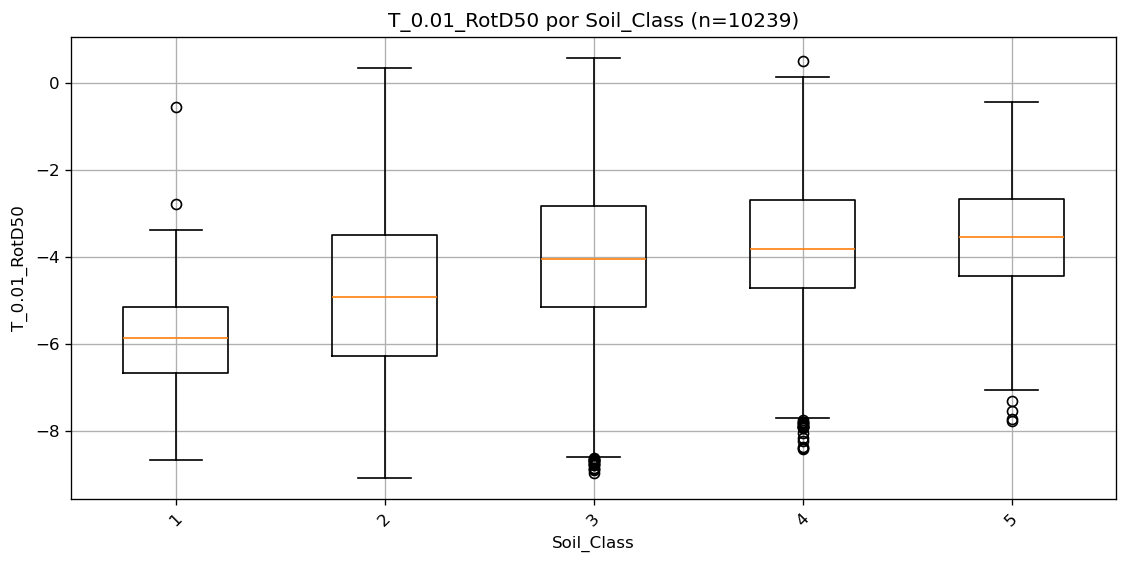

In [8]:
cat = "Soil_Class"
val = "T_0.01_RotD50"

d = df[[cat, val]].copy()
d[cat] = d[cat].astype("string")
d[val] = pd.to_numeric(d[val], errors="coerce")
d = d.dropna()

# ordenar clases por mediana
order = d.groupby(cat)[val].median().sort_values().index.tolist()

data = [d.loc[d[cat] == k, val].values for k in order]

plt.figure(figsize=(9.5, 4.8), dpi=120)
plt.boxplot(data, tick_labels=[str(k) for k in order], showfliers=True)
plt.title(f"{val} por {cat} (n={len(d)})")
plt.xlabel(cat)
plt.ylabel(val)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Hay un cambio entre clases ya que, las medianas y los rangos intercuartílicos no son iguales. Se observa diferencia de dispersión entre clases. Algunas clases tienen más outliers. Soil_Class está asociado no solo al nivel típico de T_0.01_RotD50, sino también a su variabilidad.

### T_0.01_RotD50 vs Origen

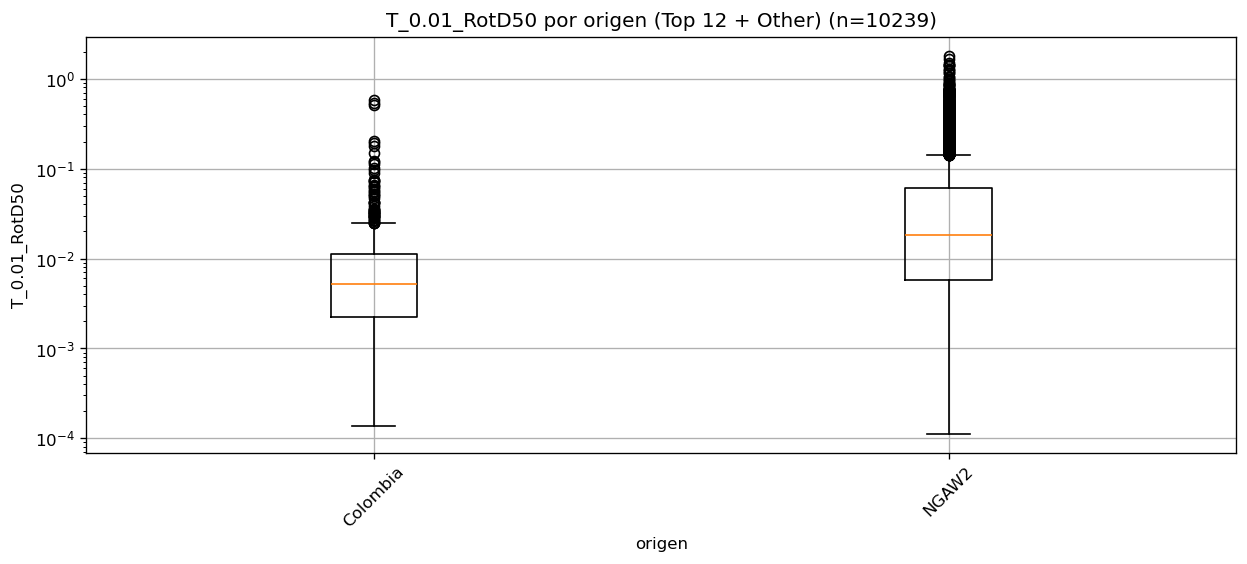

In [9]:
cat = "origen"
val = "T_0.01_RotD50"
top_k = 12

d = df[[cat, val]].copy()
d[cat] = d[cat].astype("string")
d[val] = np.exp(pd.to_numeric(d[val], errors="coerce"))
d = d.dropna()

top = d[cat].value_counts().head(top_k).index
d.loc[~d[cat].isin(top), cat] = "Other"

order = d.groupby(cat)[val].median().sort_values().index.tolist()
data = [d.loc[d[cat] == k, val].values for k in order]

plt.figure(figsize=(10.5, 4.8), dpi=120)
plt.boxplot(data, tick_labels=[str(k) for k in order], showfliers=True)
plt.title(f"{val} por {cat} (Top {top_k} + Other) (n={len(d)})")
plt.xlabel(cat)
plt.ylabel(val)
plt.xticks(rotation=45)
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

Las distribuciones son distintas. NGAW2 muestra mediana mayor y también más variabilidad/outliers en amplitudes altas.Colombia está desplazado hacia valores más bajos. Con esto se concluye que el origen es una fuente de heterogeneidad.

### Magnitude vs Rrup_OpenQuake

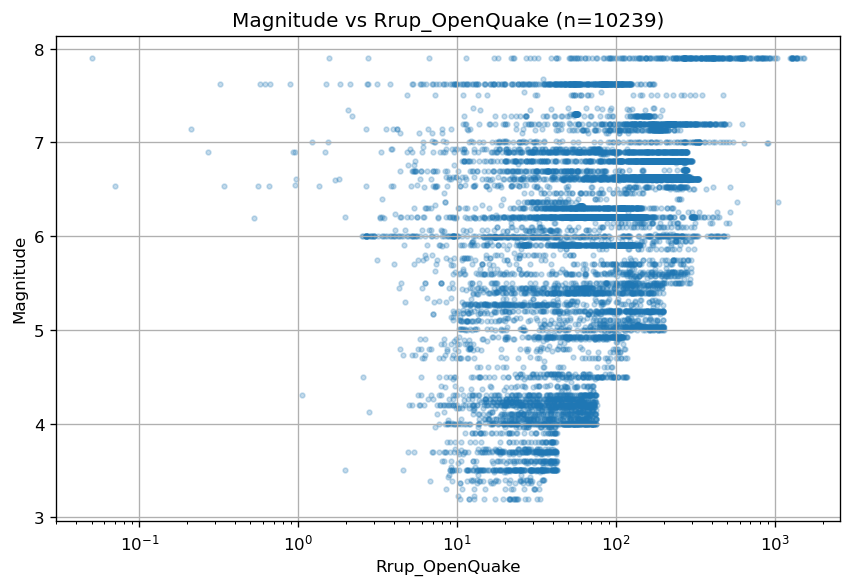

In [10]:
ycol = "Magnitude"
xcol = "Rrup_OpenQuake"

d = df[[xcol, ycol]].copy()
d[xcol] = pd.to_numeric(np.exp(d[xcol]), errors="coerce")
d[ycol] = pd.to_numeric(d[ycol], errors="coerce")
d = d.dropna()

plt.figure(figsize=(7.2, 5.0), dpi=120)
plt.scatter(d[xcol], d[ycol], s=8, alpha=0.25)
plt.title(f"{ycol} vs {xcol} (n={len(d)})")
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.xscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

Se puede evidenciar una forma de escalera que va subiendo por la derecha. Esto se da gracias al filtrado inicial antes de recibir el dataset que usa la distancia hipocentral y la magnitud por bines de 0.5. 

### Magnitude vs Hypocenter Depth

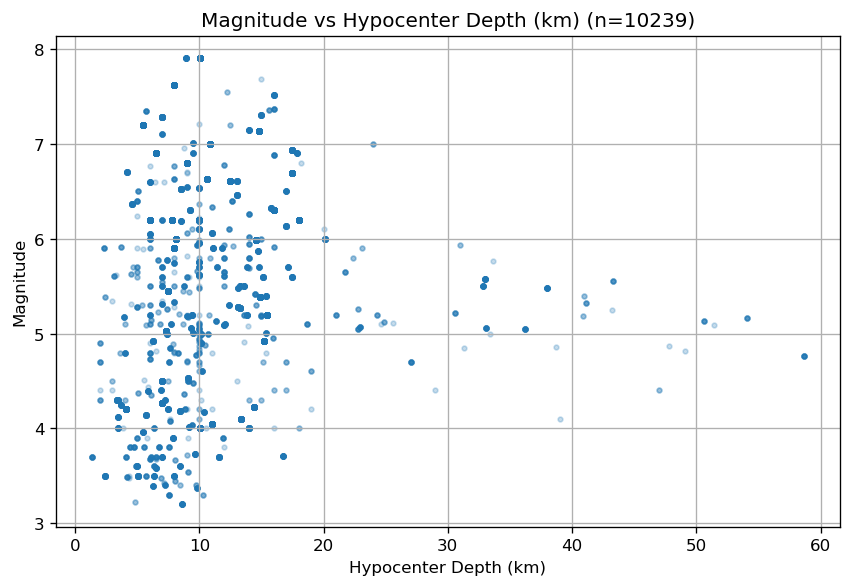

In [11]:

ycol = "Magnitude"
xcol = "Hypocenter Depth (km)"

d = df[[xcol, ycol]].copy()
d[xcol] = pd.to_numeric(d[xcol], errors="coerce")
d[ycol] = pd.to_numeric(d[ycol], errors="coerce")
d = d.dropna()

plt.figure(figsize=(7.2, 5.0), dpi=120)
plt.scatter(d[xcol], d[ycol], s=8, alpha=0.25)
plt.title(f"{ycol} vs {xcol} (n={len(d)})")
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.grid(True)
plt.tight_layout()
plt.show()

No se ve una relación fuerte entre magnitud y profundidad en el grueso de datos: magnitudes 3.5–8 aparecen mayoritariamente a profundidades 5–15 km. Los profundos (>30 km) son pocos y no muestran un patrón claro de magnitudes extremas pareciendo outliers

### Mapa global de calor usando la clasificación Soil_Class 

In [12]:
d = df[["Station Latitude", "Station Longitude", "Soil_Class"]].copy()
d["Station Latitude"] = pd.to_numeric(d["Station Latitude"], errors="coerce")
d["Station Longitude"] = pd.to_numeric(d["Station Longitude"], errors="coerce")
d = d.dropna()

fig = px.scatter_geo(
    d,
    lat="Station Latitude",
    lon="Station Longitude",
    color="Soil_Class",
    projection="natural earth",
    title=f"Estaciones — Mapa global por Soil_Class (n={len(d)})",
)

fig.update_traces(marker=dict(size=4, opacity=0.6))
fig.update_layout(height=520, legend_title_text="Soil_Class")
fig
HTML(pio.to_html(fig, include_plotlyjs="cdn", full_html=False))

### Mapa de calor de eventos usando magnitud del evento

In [13]:
d = df[["Seismic Latitude", "Seismic Longitude", "Magnitude"]].copy()
d["Seismic Latitude"] = pd.to_numeric(d["Seismic Latitude"], errors="coerce")
d["Seismic Longitude"] = pd.to_numeric(d["Seismic Longitude"], errors="coerce")
d["Magnitude"] = pd.to_numeric(d["Magnitude"], errors="coerce")
d = d.dropna()

fig = px.density_map(
    d,
    lat="Seismic Latitude",
    lon="Seismic Longitude",
    z="Magnitude",           
    radius=6,
    zoom=1,
    center=dict(lat=0, lon=0),
    title=f"Mapa de calor ponderado por Magnitude — Eventos (n={len(d)})",
    map_style="carto-positron"
)

fig.update_layout(height=600)
fig
HTML(pio.to_html(fig, include_plotlyjs="cdn", full_html=False))

### Tablas de contingencia para variables categóricas

In [14]:
from scipy.stats import chi2_contingency

d = df[["origen", "Soil_Class"]].copy()
d["origen"] = d["origen"].astype("string").fillna("NA")
d["Soil_Class"] = d["Soil_Class"].astype("string").fillna("NA")

ct = pd.crosstab(d["origen"], d["Soil_Class"], dropna=False)
print(ct)

Soil_Class    1     2     3     4    5
origen                                
Colombia    110   132   173    78   44
NGAW2         0  1439  5880  1988  395


Se puede evidenciar que para la clase 1, no existen registros por fuera de los colombianos. Para ambos grupos, la clase 3 sigue siendo la que mas cantidad de datos posee, siguiéndole la clase 3 y 4.

In [15]:
# Chi-cuadrado de independencia
chi2, p, dof, expected = chi2_contingency(ct.values)

n = ct.values.sum()
r, c = ct.shape
cramers_v = np.sqrt(chi2 / (n * (min(r - 1, c - 1)))) if min(r - 1, c - 1) > 0 else np.nan

summary = pd.DataFrame([{
    "n": int(n),
    "chi2": float(chi2),
    "dof": int(dof),
    "p_value": float(p),
    "cramers_v": float(cramers_v)
}])

print(summary)

       n         chi2  dof  p_value  cramers_v
0  10239  2117.409991    4      0.0   0.454751


Con la X2 se rechaza independencia, origen y Soil_Class están fuertemente asociados. La distribución de clases de suelo no es la misma en Colombia y en NGAW2.

Para cuantificar qué tan fuerte es esa asociación se usa Cramér, que es un tamaño de efecto para tablas de contingencia (de 0 a 1). Aquí V=0.455, lo que implica una asociación moderada por lo que la diferencia entre orígenes es significativa.

### Contingencia en porcentajes

In [16]:
d = df[["origen", "Soil_Class"]].copy()
d["origen"] = d["origen"].astype("string").fillna("NA")
d["Soil_Class"] = d["Soil_Class"].astype("string").fillna("NA")

ct = pd.crosstab(d["origen"], d["Soil_Class"], dropna=False)

row_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)   # % por fila
col_pct = (ct.div(ct.sum(axis=0), axis=1) * 100).round(2)   # % por columna

print("% por fila (distribución de Soil_Class dentro de cada origen)")
print(row_pct)



% por fila (distribución de Soil_Class dentro de cada origen)
Soil_Class      1      2      3      4     5
origen                                      
Colombia    20.48  24.58  32.22  14.53  8.19
NGAW2        0.00  14.83  60.61  20.49  4.07


In [17]:
print("% por columna (distribución de origen dentro de cada Soil_Class)")
print(col_pct)

% por columna (distribución de origen dentro de cada Soil_Class)
Soil_Class      1     2      3      4      5
origen                                      
Colombia    100.0   8.4   2.86   3.78  10.02
NGAW2         0.0  91.6  97.14  96.22  89.98


### Test de levene para varianzas

In [18]:
from scipy.stats import levene

cat = "Soil_Class"          
val = "T_0.01_RotD50"

d = df[[cat, val]].copy()
d[cat] = d[cat].astype("string").fillna("NA")
d[val] = pd.to_numeric(d[val], errors="coerce")
d = d.dropna(subset=[val])

groups = [g[val].values for _, g in d.groupby(cat) if len(g) >= 5]
W, p = levene(*groups, center="median")

print(f"Levene (center=median): varianza de {val} por {cat}")
print("W =", float(W), "p_value =", float(p))

Levene (center=median): varianza de T_0.01_RotD50 por Soil_Class
W = 31.791922495960808 p_value = 2.2955644481516956e-26


Aplicando la prueba de Levene para comparar varianzas de T_0.01_RotD50 entre categorías de Soil_Class, se obtuvo p=2.30×10⁻²⁶, indicando varianzas distintas entre clases al rechazar la hipotesis nula.